In [8]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [9]:
# Creating arrays, uploading the images, resizing them and making them black & white
x = np.empty((0 , 1024))
y = np.array([])
for k in range(1 , 22):
    files = os.listdir('pelak/' + str(k))
    for filename in files:
        img = cv2.imread('pelak/' + str(k) + '/' + filename)
        img2 = cv2.resize(img , (16 , 64))
        img3 = cv2.cvtColor(img2 , cv2.COLOR_BGR2GRAY)
        img4 = img3.flatten()
        x = np.append(x , [img4] , axis = 0)
        y = np.append(y , k)

In [10]:
# Splitting the data
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2, stratify = y)

In [11]:
# Training model
knn = KNeighborsClassifier(n_neighbors = 20)
knn.fit(X_train , y_train)

,n_neighbors,20
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
# Predicting
knn_pred = knn.predict(X_test)

In [13]:
# Model accuracy
accuracy_score(y_test , knn_pred)

0.770949720670391

<Axes: >

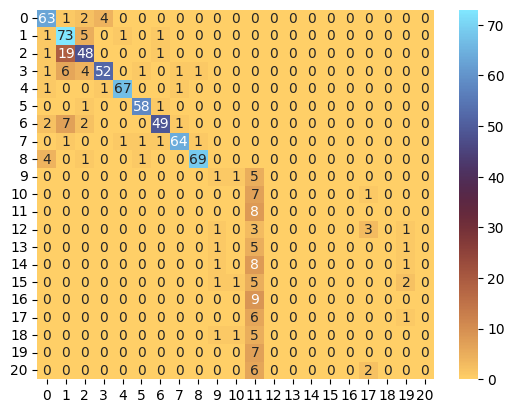

In [ ]:
# Understanding the model's errors
sns.heatmap(confusion_matrix(y_test , knn_pred) , annot = True , cmap = 'managua')

In [15]:
# Uploading a practical example
img_pelak = cv2.imread('pelak/test/test.png')
img_pelak0 = cv2.imread('pelak/test/test.png' , 0)
ret , img_pelak = cv2.threshold(img_pelak , 3 , 255 , cv2.THRESH_BINARY)
cv2.imshow('pic' , img_pelak)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [16]:
# Detecting the blank spaces between the plate numbers
s = 90- (np.sum(img_pelak0 , axis = 0 , keepdims = True) /255)

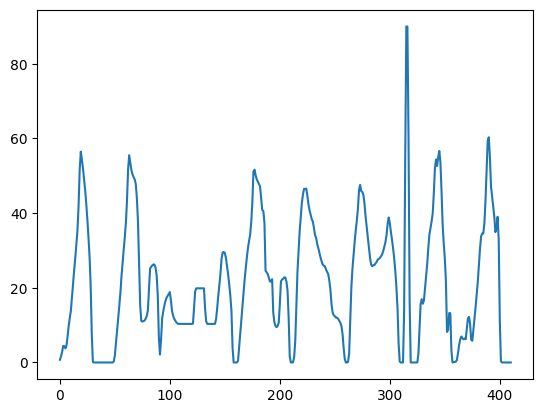

In [17]:
# Showing them in a plot
plt.close()
plt.plot(s[0])
plt.show()

In [18]:
# Drawing lines in the blank spaces
pelak = img_pelak.copy()
pelak = cv2.line(pelak , (93 , 0) , (93 , 90) , (200 , 81 , 169) , 2)

In [19]:
# Splitting numbers and predicting them
pelak = img_pelak.copy()
xi = 0
flag1 = False
flag2 = False
xi1 = 0
xi2 = 0
for i in s[0]:
    xi += 1
    if i > 9 and flag1 == True and flag2 == False:
        flag2 = True
    if i < 5:
        pelak = cv2.line(pelak , (xi , 0) , (xi , 90) , (190 , 81 , 169) , 1)
        if flag1 == False:
            xi1 = xi
        if flag2 == True:
            xi2 = xi
            flag2 = False
            flag1 = False
            img1 = img_pelak[: , xi1 : xi2]
            x1 = np.empty((0 , 1024))
            imag2 = cv2.resize(img1 , (16 , 64))
            imag3 = cv2.cvtColor(imag2 , cv2.COLOR_BGR2GRAY)
            imag4 = imag3.flatten()
            x1 = np.append(x1 , [imag4] , axis = 0)
            result2 = knn.predict(x1)
            print(result2)
            cv2.imshow('pic' , img1)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
            xi1 = xi2
        flag1 = True

[1.]
[2.]
[10.]
[2.]
[6.]
[5.]
[11.]
[1.]
[1.]
